In [2]:
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_sat_path = '../../data/LandSat/result_EarthExplorer_region_ARA.csv'
df_sat = pd.read_csv(data_sat_path, encoding='ISO-8859-1', sep=';')
df_sat.describe(include='all')

,Landsat Product Identifier L2,Landsat Product Identifier L1,Landsat Scene Identifier,Date Acquired,Collection Category,Collection Number,WRS Path,WRS Row,Target WRS Path,Target WRS Row,...,Corner Upper Left Latitude,Corner Upper Left Longitude,Corner Upper Right Latitude,Corner Upper Right Longitude,Corner Lower Left Latitude,Corner Lower Left Longitude,Corner Lower Right Latitude,Corner Lower Right Longitude,Display ID,Entity ID
count,4425,4425,4425,4425,4425,4425.0,4425.000000,4425.000000,4425.000000,4425.000000,...,4425.000000,4425.000000,4425.000000,4425.000000,4425.000000,4425.000000,4425.000000,4425.000000,4425,4425
unique,4425,4425,4425,1850,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4425,4425
top,LC08_L2SP_196028_20130322_20200913_02_T1,LC08_L1TP_196028_20130322_20200913_02_T1,LC81960282013081LGN02,09/11/2021,T1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LC08_L2SP_196028_20130322_20200913_02_T1,LC81960282013081LGN02
freq,1,1,1,5,3767,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
mean,NaN,NaN,NaN,NaN,NaN,2.0,196.912090,28.334915,196.912090,28.334915,...,46.605133,2.754910,46.611368,5.820964,44.466045,2.820426,44.471794,5.772208,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.0,1.443073,0.849377,1.443073,0.849377,...,1.210538,2.019721,1.203112,1.984046,1.211074,2.015235,1.203283,1.984057,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2.0,194.000000,27.000000,194.000000,27.000000,...,44.162780,-0.644670,44.230210,2.380820,42.044510,-0.511950,42.117810,2.403420,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.0,195.000000,28.000000,195.000000,28.000000,...,45.659210,1.163610,45.646690,4.258310,43.542480,1.233210,43.528600,4.210540,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2.0,197.000000,28.000000,197.000000,28.000000,...,47.073580,2.776000,47.024620,5.833630,44.910870,2.784410,44.935520,5.727500,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2.0,198.000000,29.000000,198.000000,29.000000,...,47.092920,4.806280,47.120000,7.782960,45.002830,4.951840,44.954350,7.825340,NaN,NaN


In [4]:
df_sat.columns

Index(['Landsat Product Identifier L2', 'Landsat Product Identifier L1',
       'Landsat Scene Identifier', 'Date Acquired', 'Collection Category',
       'Collection Number', 'WRS Path', 'WRS Row', 'Target WRS Path',
       'Target WRS Row', 'Nadir/Off Nadir', 'Roll Angle',
       'Date Product Generated L2', 'Date Product Generated L1', 'Start Time',
       'Stop Time', 'Station Identifier', 'Day/Night Indicator',
       'Land Cloud Cover', 'Scene Cloud Cover L1',
       'Ground Control Points Model', 'Ground Control Points Version',
       'Geometric RMSE Model', 'Geometric RMSE Model X',
       'Geometric RMSE Model Y', 'Processing Software Version',
       'Sun Elevation L0RA', 'Sun Azimuth L0RA', 'TIRS SSM Model',
       'Data Type L2', 'Sensor Identifier', 'Satellite',
       'Product Map Projection L1', 'UTM Zone', 'Datum', 'Ellipsoid',
       'Scene Center Lat DMS', 'Scene Center Long DMS',
       'Corner Upper Left Lat DMS', 'Corner Upper Left Long DMS',
       'Corner Upper 

In [5]:
df_sat[['Sun Elevation L0RA', 'Sun Azimuth L0RA']]

,Sun Elevation L0RA,Sun Azimuth L0RA
0,41.526887,153.113939
1,42.653073,151.988002
2,44.647106,151.635940
3,45.753396,150.411723
4,43.588805,153.851387
...,...,...
4420,27.437137,164.566567
4421,28.725738,163.913149
4422,26.837969,164.688615
4423,28.127729,164.046132


In [6]:
sat_columns = ['Date Acquired','Start Time', 'Stop Time', 'Day/Night Indicator', 'Land Cloud Cover', 'Scene Cloud Cover L1', 'Sun Elevation L0RA', 'Sun Azimuth L0RA']
data_sat = df_sat[sat_columns].copy()
data_sat

,Date Acquired,Start Time,Stop Time,Day/Night Indicator,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA
0,22/03/2013,2013-03-22 10:21:51.325364,2013-03-22 10:22:21.121385,DAY,38.60,38.60,41.526887,153.113939
1,22/03/2013,2013-03-22 10:22:15.118974,2013-03-22 10:22:44.914994,DAY,38.80,38.80,42.653073,151.988002
2,27/03/2013,2013-03-27 10:18:01.201336,2013-03-27 10:18:30.997357,DAY,38.27,38.79,44.647106,151.635940
3,27/03/2013,2013-03-27 10:18:24.986474,2013-03-27 10:18:54.782494,DAY,37.17,64.70,45.753396,150.411723
4,30/03/2013,2013-03-30 10:34:23.762667,2013-03-30 10:34:53.558688,DAY,93.15,93.15,43.588805,153.851387
...,...,...,...,...,...,...,...,...
4420,03/11/2025,03/11/2025 10:29,03/11/2025 10:29,DAY,80.98,80.98,27.437137,164.566567
4421,03/11/2025,03/11/2025 10:29,03/11/2025 10:30,DAY,44.91,44.91,28.725738,163.913149
4422,05/11/2025,05/11/2025 10:16,05/11/2025 10:17,DAY,7.73,7.73,26.837969,164.688615
4423,05/11/2025,05/11/2025 10:17,05/11/2025 10:17,DAY,2.64,2.58,28.127729,164.046132


In [7]:
data_sat.describe(include='all')

,Date Acquired,Start Time,Stop Time,Day/Night Indicator,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA
count,4425,4425,4425,4425,4425.000000,4425.000000,4425.000000,4425.000000
unique,1850,3703,3780,1,NaN,NaN,NaN,NaN
top,09/11/2021,13/01/2023 10:35,03/04/2023 10:35,DAY,NaN,NaN,NaN,NaN
freq,5,3,3,4425,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,48.555661,48.413998,42.243104,152.455603
std,NaN,NaN,NaN,NaN,35.131281,35.030020,15.516280,8.651400
min,NaN,NaN,NaN,NaN,0.000000,0.000000,17.344676,133.515367
25%,NaN,NaN,NaN,NaN,13.230000,13.230000,26.853927,145.184317
50%,NaN,NaN,NaN,NaN,48.190000,48.030000,43.614632,153.035696
75%,NaN,NaN,NaN,NaN,82.460000,82.100000,57.462832,160.261952


In [8]:
data_sat['Date'] = pd.to_datetime(data_sat['Date Acquired'], format='%d/%m/%Y')
data_sat['Date'].head()

0   2013-03-22
1   2013-03-22
2   2013-03-27
3   2013-03-27
4   2013-03-30
Name: Date, dtype: datetime64[ns]

In [9]:
data_sat.head()

,Date Acquired,Start Time,Stop Time,Day/Night Indicator,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA,Date
0,22/03/2013,2013-03-22 10:21:51.325364,2013-03-22 10:22:21.121385,DAY,38.60,38.60,41.526887,153.113939,2013-03-22
1,22/03/2013,2013-03-22 10:22:15.118974,2013-03-22 10:22:44.914994,DAY,38.80,38.80,42.653073,151.988002,2013-03-22
2,27/03/2013,2013-03-27 10:18:01.201336,2013-03-27 10:18:30.997357,DAY,38.27,38.79,44.647106,151.635940,2013-03-27
3,27/03/2013,2013-03-27 10:18:24.986474,2013-03-27 10:18:54.782494,DAY,37.17,64.70,45.753396,150.411723,2013-03-27
4,30/03/2013,2013-03-30 10:34:23.762667,2013-03-30 10:34:53.558688,DAY,93.15,93.15,43.588805,153.851387,2013-03-30


In [10]:
data_sat.groupby(data_sat['Date'].dt.to_period('D'))[['Land Cloud Cover', 'Scene Cloud Cover L1']].mean()

,Land Cloud Cover,Scene Cloud Cover L1
Date,,
2013-03-22,38.700000,38.700000
2013-03-27,37.720000,51.745000
2013-03-30,91.826667,91.826667
2013-04-01,90.870000,85.820000
2013-04-04,85.410000,85.410000
...,...,...
2025-10-11,30.000000,30.000000
2025-10-16,8.195000,8.195000
2025-11-01,99.990000,99.990000


In [11]:
data_prod_path = '../../data/prod/eCO2mix_RTE_Auvergne-Rhone-Alpes_cleaned.csv'
df_prod = pd.read_csv(data_prod_path)
df_prod.describe(include='all')

,nature,date,heures,consommation,thermique,nucléaire,eolien,solaire,hydraulique,pompage,...,tco_nucléaire_(%),tch_nucléaire_(%),tco_eolien_(%),tch_eolien_(%),tco_solaire_(%),tch_solaire_(%),tco_hydraulique_(%),tch_hydraulique_(%),tco_bioénergies_(%),tch_bioénergies_(%)
count,52560,52560,52560,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,...,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
unique,1,1095,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Données définitives,2021-01-01,00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,52560,48,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,7190.969597,246.527435,9167.504091,162.299962,235.225951,2911.284342,-404.372679,...,129.481027,67.557150,2.298257,23.767502,3.367090,14.719464,41.011498,25.285134,1.670323,59.941966
std,NaN,NaN,NaN,1530.426393,221.845994,1957.762228,119.448308,356.864617,1232.699432,569.642105,...,23.930242,14.427161,1.734516,17.573202,5.252393,21.784531,16.443089,10.646330,0.394794,5.583063
min,NaN,NaN,NaN,3616.000000,4.000000,3906.000000,0.000000,0.000000,588.000000,-2580.000000,...,62.560000,28.780000,0.000000,0.000000,0.000000,0.000000,8.470000,5.130000,0.750000,38.740000
25%,NaN,NaN,NaN,6006.000000,14.000000,7648.750000,64.000000,0.000000,1973.750000,-723.000000,...,112.580000,56.367500,0.920000,9.410000,0.000000,0.000000,28.550000,17.190000,1.380000,56.680000
50%,NaN,NaN,NaN,7008.000000,198.000000,9018.000000,137.000000,3.000000,2801.000000,-17.000000,...,126.210000,66.460000,1.900000,19.890000,0.040000,0.160000,39.050000,24.390000,1.620000,60.530000
75%,NaN,NaN,NaN,8170.250000,414.000000,10624.000000,236.000000,392.250000,3671.000000,-13.000000,...,144.250000,78.290000,3.290000,34.550000,5.330000,25.290000,51.720000,31.760000,1.920000,63.870000


In [12]:
df_prod.columns

Index(['nature', 'date', 'heures', 'consommation', 'thermique', 'nucléaire',
       'eolien', 'solaire', 'hydraulique', 'pompage', 'bioénergies',
       'stockage_batterie', 'déstockage_batterie', 'eolien_terrestre',
       'eolien_offshore', 'ech._physiques',
       'flux_physiques_d'auvergne-rhône-alpes_vers_auvergne-rhône-alpes',
       'flux_physiques_de_bourgogne-franche-comté_vers_auvergne-rhône-alpes',
       'flux_physiques_de_bretagne_vers_auvergne-rhône-alpes',
       'flux_physiques_de_centre-val_de_loire_vers_auvergne-rhône-alpes',
       'flux_physiques_de_grand-est_vers_auvergne-rhône-alpes',
       'flux_physiques_de_hauts-de-france_vers_auvergne-rhône-alpes',
       'flux_physiques_d'ile-de-france_vers_auvergne-rhône-alpes',
       'flux_physiques_de_normandie_vers_auvergne-rhône-alpes',
       'flux_physiques_de_nouvelle-aquitaine_vers_auvergne-rhône-alpes',
       'flux_physiques_d'occitanie_vers_auvergne-rhône-alpes',
       'flux_physiques_de_pays-de-la-loire_vers_a

In [13]:
df_prod.head()

,nature,date,heures,consommation,thermique,nucléaire,eolien,solaire,hydraulique,pompage,...,tco_nucléaire_(%),tch_nucléaire_(%),tco_eolien_(%),tch_eolien_(%),tco_solaire_(%),tch_solaire_(%),tco_hydraulique_(%),tch_hydraulique_(%),tco_bioénergies_(%),tch_bioénergies_(%)
0,Données définitives,2021-01-01,00:00:00,8586.0,156.0,10710.0,66.0,0.0,3096.0,-166.0,...,124.74,78.92,0.77,11.81,0.0,0.0,36.06,26.25,1.55,71.12
1,Données définitives,2021-01-01,00:30:00,8373.0,179.0,10622.0,64.0,0.0,2977.0,-163.0,...,126.86,78.28,0.76,11.45,0.0,0.0,35.55,25.24,1.45,64.71
2,Données définitives,2021-01-01,01:00:00,8134.0,181.0,10652.0,58.0,0.0,2667.0,-163.0,...,130.96,78.50,0.71,10.38,0.0,0.0,32.79,22.61,1.49,64.71
3,Données définitives,2021-01-01,01:30:00,8130.0,179.0,10662.0,54.0,0.0,2592.0,-163.0,...,131.14,78.57,0.66,9.66,0.0,0.0,31.88,21.98,1.50,65.24
4,Données définitives,2021-01-01,02:00:00,8102.0,181.0,10600.0,42.0,0.0,2827.0,-165.0,...,130.83,78.11,0.52,7.51,0.0,0.0,34.89,23.97,1.48,64.17


In [14]:
prod_columns = ['date','heures', 'solaire', 'tco_solaire_(%)', 'tch_solaire_(%)']
data_prod = df_prod[prod_columns].copy()
data_prod

,date,heures,solaire,tco_solaire_(%),tch_solaire_(%)
0,2021-01-01,00:00:00,0.0,0.0,0.0
1,2021-01-01,00:30:00,0.0,0.0,0.0
2,2021-01-01,01:00:00,0.0,0.0,0.0
3,2021-01-01,01:30:00,0.0,0.0,0.0
4,2021-01-01,02:00:00,0.0,0.0,0.0
...,...,...,...,...,...
52558,2023-12-31,22:00:00,0.0,0.0,0.0
52559,2023-12-31,22:30:00,0.0,0.0,0.0
52560,2023-12-31,23:00:00,0.0,0.0,0.0
52561,2023-12-31,23:30:00,0.0,0.0,0.0


In [15]:
data_prod['date'].dtype

dtype('O')

In [16]:
data_prod['heures'].dtype

dtype('O')

In [17]:
data_prod['Time'] = data_prod['date']+" "+data_prod['heures']

In [18]:
data_prod['Time'] = pd.to_datetime(data_prod['Time'])

In [19]:
data_prod

,date,heures,solaire,tco_solaire_(%),tch_solaire_(%),Time
0,2021-01-01,00:00:00,0.0,0.0,0.0,2021-01-01 00:00:00
1,2021-01-01,00:30:00,0.0,0.0,0.0,2021-01-01 00:30:00
2,2021-01-01,01:00:00,0.0,0.0,0.0,2021-01-01 01:00:00
3,2021-01-01,01:30:00,0.0,0.0,0.0,2021-01-01 01:30:00
4,2021-01-01,02:00:00,0.0,0.0,0.0,2021-01-01 02:00:00
...,...,...,...,...,...,...
52558,2023-12-31,22:00:00,0.0,0.0,0.0,2023-12-31 22:00:00
52559,2023-12-31,22:30:00,0.0,0.0,0.0,2023-12-31 22:30:00
52560,2023-12-31,23:00:00,0.0,0.0,0.0,2023-12-31 23:00:00
52561,2023-12-31,23:30:00,0.0,0.0,0.0,2023-12-31 23:30:00


In [20]:
data_prod['Time'].dtype

dtype('<M8[ns]')

In [21]:
data_sat['Start Time'].dtype

dtype('O')

In [22]:
data_sat

,Date Acquired,Start Time,Stop Time,Day/Night Indicator,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA,Date
0,22/03/2013,2013-03-22 10:21:51.325364,2013-03-22 10:22:21.121385,DAY,38.60,38.60,41.526887,153.113939,2013-03-22
1,22/03/2013,2013-03-22 10:22:15.118974,2013-03-22 10:22:44.914994,DAY,38.80,38.80,42.653073,151.988002,2013-03-22
2,27/03/2013,2013-03-27 10:18:01.201336,2013-03-27 10:18:30.997357,DAY,38.27,38.79,44.647106,151.635940,2013-03-27
3,27/03/2013,2013-03-27 10:18:24.986474,2013-03-27 10:18:54.782494,DAY,37.17,64.70,45.753396,150.411723,2013-03-27
4,30/03/2013,2013-03-30 10:34:23.762667,2013-03-30 10:34:53.558688,DAY,93.15,93.15,43.588805,153.851387,2013-03-30
...,...,...,...,...,...,...,...,...,...
4420,03/11/2025,03/11/2025 10:29,03/11/2025 10:29,DAY,80.98,80.98,27.437137,164.566567,2025-11-03
4421,03/11/2025,03/11/2025 10:29,03/11/2025 10:30,DAY,44.91,44.91,28.725738,163.913149,2025-11-03
4422,05/11/2025,05/11/2025 10:16,05/11/2025 10:17,DAY,7.73,7.73,26.837969,164.688615,2025-11-05
4423,05/11/2025,05/11/2025 10:17,05/11/2025 10:17,DAY,2.64,2.58,28.127729,164.046132,2025-11-05


In [23]:
data_sat['Time1'] = pd.to_datetime(data_sat['Start Time'].str[:16], format='%d/%m/%Y %H:%M', errors='coerce')


In [24]:
data_sat['Time2'] = pd.to_datetime(data_sat['Start Time'].str[:16], format='%Y-%m-%d %H:%M', errors='coerce')

In [25]:
data_sat['Time'] = data_sat['Time1'].fillna(data_sat['Time2'])


In [26]:
data_sat

,Date Acquired,Start Time,Stop Time,Day/Night Indicator,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA,Date,Time1,Time2,Time
0,22/03/2013,2013-03-22 10:21:51.325364,2013-03-22 10:22:21.121385,DAY,38.60,38.60,41.526887,153.113939,2013-03-22,NaT,2013-03-22 10:21:00,2013-03-22 10:21:00
1,22/03/2013,2013-03-22 10:22:15.118974,2013-03-22 10:22:44.914994,DAY,38.80,38.80,42.653073,151.988002,2013-03-22,NaT,2013-03-22 10:22:00,2013-03-22 10:22:00
2,27/03/2013,2013-03-27 10:18:01.201336,2013-03-27 10:18:30.997357,DAY,38.27,38.79,44.647106,151.635940,2013-03-27,NaT,2013-03-27 10:18:00,2013-03-27 10:18:00
3,27/03/2013,2013-03-27 10:18:24.986474,2013-03-27 10:18:54.782494,DAY,37.17,64.70,45.753396,150.411723,2013-03-27,NaT,2013-03-27 10:18:00,2013-03-27 10:18:00
4,30/03/2013,2013-03-30 10:34:23.762667,2013-03-30 10:34:53.558688,DAY,93.15,93.15,43.588805,153.851387,2013-03-30,NaT,2013-03-30 10:34:00,2013-03-30 10:34:00
...,...,...,...,...,...,...,...,...,...,...,...,...
4420,03/11/2025,03/11/2025 10:29,03/11/2025 10:29,DAY,80.98,80.98,27.437137,164.566567,2025-11-03,2025-11-03 10:29:00,NaT,2025-11-03 10:29:00
4421,03/11/2025,03/11/2025 10:29,03/11/2025 10:30,DAY,44.91,44.91,28.725738,163.913149,2025-11-03,2025-11-03 10:29:00,NaT,2025-11-03 10:29:00
4422,05/11/2025,05/11/2025 10:16,05/11/2025 10:17,DAY,7.73,7.73,26.837969,164.688615,2025-11-05,2025-11-05 10:16:00,NaT,2025-11-05 10:16:00
4423,05/11/2025,05/11/2025 10:17,05/11/2025 10:17,DAY,2.64,2.58,28.127729,164.046132,2025-11-05,2025-11-05 10:17:00,NaT,2025-11-05 10:17:00


In [27]:
data_sat = data_sat.drop(['Time1', 'Time2'], axis=1)

In [28]:
data_sat['Time']=data_sat['Time'].dt.round('30min')
data_sat

,Date Acquired,Start Time,Stop Time,Day/Night Indicator,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA,Date,Time
0,22/03/2013,2013-03-22 10:21:51.325364,2013-03-22 10:22:21.121385,DAY,38.60,38.60,41.526887,153.113939,2013-03-22,2013-03-22 10:30:00
1,22/03/2013,2013-03-22 10:22:15.118974,2013-03-22 10:22:44.914994,DAY,38.80,38.80,42.653073,151.988002,2013-03-22,2013-03-22 10:30:00
2,27/03/2013,2013-03-27 10:18:01.201336,2013-03-27 10:18:30.997357,DAY,38.27,38.79,44.647106,151.635940,2013-03-27,2013-03-27 10:30:00
3,27/03/2013,2013-03-27 10:18:24.986474,2013-03-27 10:18:54.782494,DAY,37.17,64.70,45.753396,150.411723,2013-03-27,2013-03-27 10:30:00
4,30/03/2013,2013-03-30 10:34:23.762667,2013-03-30 10:34:53.558688,DAY,93.15,93.15,43.588805,153.851387,2013-03-30,2013-03-30 10:30:00
...,...,...,...,...,...,...,...,...,...,...
4420,03/11/2025,03/11/2025 10:29,03/11/2025 10:29,DAY,80.98,80.98,27.437137,164.566567,2025-11-03,2025-11-03 10:30:00
4421,03/11/2025,03/11/2025 10:29,03/11/2025 10:30,DAY,44.91,44.91,28.725738,163.913149,2025-11-03,2025-11-03 10:30:00
4422,05/11/2025,05/11/2025 10:16,05/11/2025 10:17,DAY,7.73,7.73,26.837969,164.688615,2025-11-05,2025-11-05 10:30:00
4423,05/11/2025,05/11/2025 10:17,05/11/2025 10:17,DAY,2.64,2.58,28.127729,164.046132,2025-11-05,2025-11-05 10:30:00


In [29]:
(data_sat['Day/Night Indicator']=='DAY').sum()

np.int64(4425)

In [30]:
data_sat_grouped = data_sat.groupby('Time')[['Land Cloud Cover', 'Scene Cloud Cover L1','Sun Elevation L0RA', 'Sun Azimuth L0RA']].mean().reset_index()


In [31]:
data_sat_grouped

,Time,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA
0,2013-03-22 10:30:00,38.700000,38.700000,42.089980,152.550971
1,2013-03-27 10:30:00,37.720000,51.745000,45.200251,151.023832
2,2013-03-30 10:30:00,91.826667,91.826667,44.715929,152.638215
3,2013-04-01 10:00:00,90.870000,85.820000,46.617333,151.264179
4,2013-04-04 10:30:00,85.410000,85.410000,47.231502,151.680830
...,...,...,...,...,...
1869,2025-10-11 10:30:00,30.000000,30.000000,35.744752,161.343169
1870,2025-10-16 10:30:00,8.195000,8.195000,32.726588,162.971268
1871,2025-11-01 10:30:00,99.990000,99.990000,27.405058,164.755692
1872,2025-11-03 10:30:00,62.945000,62.945000,28.081437,164.239858


In [32]:
data_prod

,date,heures,solaire,tco_solaire_(%),tch_solaire_(%),Time
0,2021-01-01,00:00:00,0.0,0.0,0.0,2021-01-01 00:00:00
1,2021-01-01,00:30:00,0.0,0.0,0.0,2021-01-01 00:30:00
2,2021-01-01,01:00:00,0.0,0.0,0.0,2021-01-01 01:00:00
3,2021-01-01,01:30:00,0.0,0.0,0.0,2021-01-01 01:30:00
4,2021-01-01,02:00:00,0.0,0.0,0.0,2021-01-01 02:00:00
...,...,...,...,...,...,...
52558,2023-12-31,22:00:00,0.0,0.0,0.0,2023-12-31 22:00:00
52559,2023-12-31,22:30:00,0.0,0.0,0.0,2023-12-31 22:30:00
52560,2023-12-31,23:00:00,0.0,0.0,0.0,2023-12-31 23:00:00
52561,2023-12-31,23:30:00,0.0,0.0,0.0,2023-12-31 23:30:00


In [33]:
data_prod['Time'].dtype

dtype('<M8[ns]')

In [34]:
data_sat_grouped['Time'].dtype

dtype('<M8[ns]')

In [35]:
merge_data = data_sat_grouped.merge(data_prod, on='Time', how='inner')
merge_data

,Time,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA,date,heures,solaire,tco_solaire_(%),tch_solaire_(%)
0,2021-01-02 10:30:00,93.360000,93.073333,20.147222,160.657325,2021-01-02,10:30:00,36.0,0.41,3.03
1,2021-01-07 10:30:00,65.546667,65.546667,19.315672,160.537883,2021-01-07,10:30:00,125.0,1.12,10.50
2,2021-01-09 10:30:00,80.515000,80.515000,20.151115,159.976130,2021-01-09,10:30:00,120.0,1.17,10.08
3,2021-01-14 10:30:00,95.540000,95.540000,19.590634,159.869917,2021-01-14,10:30:00,167.0,1.64,14.03
4,2021-01-16 10:30:00,40.080000,40.080000,21.132299,158.999407,2021-01-16,10:30:00,201.0,2.03,16.89
...,...,...,...,...,...,...,...,...,...,...
575,2023-12-24 10:30:00,12.510000,12.510000,19.250592,162.155437,2023-12-24,10:30:00,579.0,7.66,25.93
576,2023-12-25 10:30:00,2.540000,2.540000,19.249214,162.051455,2023-12-25,10:30:00,554.0,7.54,24.81
577,2023-12-26 10:30:00,32.986667,31.113333,19.876064,161.634882,2023-12-26,10:30:00,515.0,6.16,23.06
578,2023-12-30 10:30:00,92.300000,92.300000,18.078856,161.966733,2023-12-30,10:30:00,497.0,6.65,22.26


In [36]:
px.scatter(merge_data, x='Time', y=['Land Cloud Cover', 'Sun Elevation L0RA', 'Sun Azimuth L0RA', 'tch_solaire_(%)'])

In [37]:
px.scatter(merge_data, x='Land Cloud Cover', y='tch_solaire_(%)', trendline='ols')

In [38]:
import seaborn as sns

<Axes: xlabel='Land Cloud Cover', ylabel='tch_solaire_(%)'>

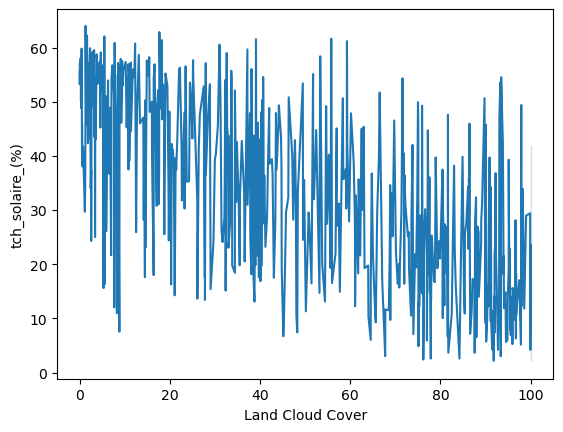

In [39]:
sns.lineplot(merge_data, x='Land Cloud Cover', y='tch_solaire_(%)')

In [40]:
merge_data['Cloud'] = pd.cut(merge_data['Land Cloud Cover'], bins=10, labels=range(5,100,10))

In [41]:
merge_data

,Time,Land Cloud Cover,Scene Cloud Cover L1,Sun Elevation L0RA,Sun Azimuth L0RA,date,heures,solaire,tco_solaire_(%),tch_solaire_(%),Cloud
0,2021-01-02 10:30:00,93.360000,93.073333,20.147222,160.657325,2021-01-02,10:30:00,36.0,0.41,3.03,95
1,2021-01-07 10:30:00,65.546667,65.546667,19.315672,160.537883,2021-01-07,10:30:00,125.0,1.12,10.50,65
2,2021-01-09 10:30:00,80.515000,80.515000,20.151115,159.976130,2021-01-09,10:30:00,120.0,1.17,10.08,85
3,2021-01-14 10:30:00,95.540000,95.540000,19.590634,159.869917,2021-01-14,10:30:00,167.0,1.64,14.03,95
4,2021-01-16 10:30:00,40.080000,40.080000,21.132299,158.999407,2021-01-16,10:30:00,201.0,2.03,16.89,45
...,...,...,...,...,...,...,...,...,...,...,...
575,2023-12-24 10:30:00,12.510000,12.510000,19.250592,162.155437,2023-12-24,10:30:00,579.0,7.66,25.93,15
576,2023-12-25 10:30:00,2.540000,2.540000,19.249214,162.051455,2023-12-25,10:30:00,554.0,7.54,24.81,5
577,2023-12-26 10:30:00,32.986667,31.113333,19.876064,161.634882,2023-12-26,10:30:00,515.0,6.16,23.06,35
578,2023-12-30 10:30:00,92.300000,92.300000,18.078856,161.966733,2023-12-30,10:30:00,497.0,6.65,22.26,95


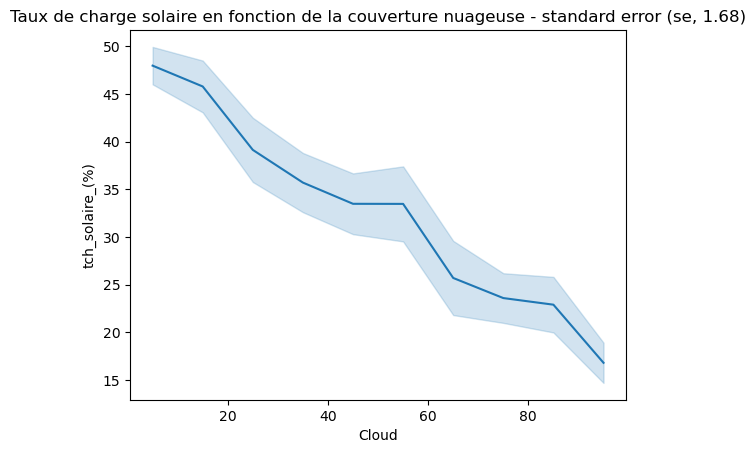

In [42]:
sns.lineplot(merge_data, x='Cloud', y='tch_solaire_(%)', errorbar=('se',1.68))
plt.title("Taux de charge solaire en fonction de la couverture nuageuse - standard error (se, 1.68)")
plt.show()


# MODELES

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from dotenv import load_dotenv
import os
import mlflow

y = merge_data['tch_solaire_(%)']
x = merge_data[['Land Cloud Cover', 'Scene Cloud Cover L1']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [61]:
# Preprocessing
sc = StandardScaler()
sc.fit(x_train)

x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

# pour enregistrer dans MLFlow
load_dotenv()

os.environ["APP_URI"] = "https://renergies99-mlflow.hf.space/"
EXPERIMENT_NAME="first_landsat_models"

mlflow.set_tracking_uri(os.environ["APP_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

mlflow.sklearn.autolog()

# model 1
run_description = """
colonnes utilisées : ['Land Cloud Cover', 'Scene Cloud Cover L1']
\n target = 'tch_solaire_(%)'
"""

with mlflow.start_run(experiment_id = experiment.experiment_id, description=run_description):
    model = LinearRegression()
    model.fit(x_train, y_train)

    score = model.score(x_test, y_test)
    
    mlflow.log_metric("ScoreR2", score)
    mlflow.sklearn.log_model(model, "model")

print('model_score_train: ', model.score(x_train,y_train))
print('model_score_test: ', model.score(x_test,y_test))




2025/11/14 12:25:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2025/11/14 12:26:09 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 3.6.0, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2025/11/14 12:26:17 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 3.6.0, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2025/11/14 12:26:17 WARNING mlflow.models.model: Model logged wi

🏃 View run masked-kit-401 at: https://renergies99-mlflow.hf.space/#/experiments/2/runs/02abb06429454879878a1378ba388ebc
🧪 View experiment at: https://renergies99-mlflow.hf.space/#/experiments/2
model_score_train:  0.42755248852228
model_score_test:  0.49000544850784566


In [45]:
print('model_score_train: ', model.score(x_train,y_train))

model_score_train:  0.42755248852228


In [46]:
print('model_score_test: ', model.score(x_test,y_test))

model_score_test:  0.49000544850784555


Modele 2 (avec 4 colonnes)

In [47]:
y = merge_data['tch_solaire_(%)']
x2 = merge_data[['Land Cloud Cover', 'Scene Cloud Cover L1','Sun Elevation L0RA', 'Sun Azimuth L0RA']]

x2_train, x2_test, y_train, y_test = train_test_split(x2, y, test_size=0.3, random_state=42)

# Preprocessing
sc = StandardScaler()
sc.fit(x2_train)

x2_train = sc.transform(x2_train)
x2_test = sc.transform(x2_test)

#model
model2 = LinearRegression()
model2.fit(x2_train, y_train)

print('model2_score_train: ', model2.score(x2_train,y_train))
print('model2_score_test: ', model2.score(x2_test,y_test))

model2_score_train:  0.6985527055865035
model2_score_test:  0.7659445520508777


In [48]:
model2

LinearRegression()

In [49]:
model2.coef_

array([-5.14823497, -3.67621374,  9.6087481 ,  0.71398258])